# Q-Learning for Optimal Investment
Tabular Q-learning for the optimal investment problem in a Cox–Ross–Rubinstein binomial market model (T = 3, u = 2, d = −0.5, q = 0.5) with log utility of terminal wealth.

The learned portfolio allocations are visualised after 50,000, 500,000, 5,000,000 and 50,000,000 episodes and compared with the analytical optimum. Only NumPy and Matplotlib are used, and the NumPy seed is fixed so that the figures are reproducible.

### *Note: Here I tried to implement the strict "terminal state condition" being absorbing and having a reward of zero*


### Initialisation

In [62]:
import numpy as np
import matplotlib.pyplot as plt

# Set random seed for reproducibility
np.random.seed(42)

# CRR Parameters
T = 3       # Time horizon
u = 2       # Up factor
d = -0.5    # Down factor
q = 0.5     # Probability of upward movement

# Initial state definition
P_0 = 8                             # Initial price
wealth_0 = 100                      # Initial wealth
initial_state = (0, P_0, wealth_0)  # Initial state (t = 0, P_0, wealth_0)

# Discount factor
gamma = 1

# Number of episodes to evaluate
episodes_list = [50000, 500000, 5000000, 50000000]

# Log-utility function
def log_utility(wealth, t):
    return np.log(wealth) if t == T else 0

### Set the Model

In [63]:
class CRRModel:
    def __init__(self, T, initial_state, d, u):
        """
        Initialise the CRR Model.

        Parameters:
        - T: Time horizon
        - initial_state: The initial state as a tuple (time, price, wealth)
        - d: Down factor
        - u: Up factor
        """
        self.T = T
        self.initial_state = initial_state
        self.d = d
        self.u = u
        self.q = q
        self.initial_wealth = initial_state[2]  # Wealth is extracted from initial_state
        self.states = self.get_all_states()  # Generate all possible states
        self.non_terminal_states = self.non_terminal_states()  # Get all non-terminal states

    def get_admissible_actions(self, state):
        """
        Calculate admissible actions based on price and wealth.

        Parameters:
        - state: Current state as a tuple (time, price, wealth)

        Returns:
        - List of admissible actions
        """
        t, p, w = state[0], state[1], state[2]
        
        if t >= self.T:
            return ["Terminal action"]
        
        if p <= 0:  # Prevent division by zero or negative prices
            return [0]
        
        max_num_assets = int(np.floor(w / p))
        admissible_actions = [p * i for i in range(max_num_assets + 1)]
        
        return admissible_actions

    def get_all_states(self):
        """
        Generate all possible states in the CRR Model. (Without terminal states)

        Returns:
        - List of all states as tuples (time, price, wealth)
        """
        states = [self.initial_state]

        for state in states:
            if state[0] < self.T:
                for a in self.get_admissible_actions(state):
                    for R in [self.d, self.u]:
                        new_state = (
                            state[0] + 1,
                            state[1] * (1 + R),
                            state[2] + R * a
                        )
                        if new_state not in states:
                            states.append(new_state)

        # Add terminal states for all states at time T
        terminal_state = (self.T + 1, np.nan, np.nan)
        states.append(terminal_state)     
           
        states = list(set(states))  # Remove duplicates
        states = sorted(states, key=lambda x: (x[0], x[1], x[2]))
        
        return states
    
    def non_terminal_states(self):
        """
        Get all non-terminal states in the CRR Model.

        Returns:
        - List of non-terminal states as tuples (time, price, wealth)
        """
        return [state for state in self.states if state[0] < self.T]

    def __repr__(self):
        """
        Representation of the CRR Model.

        Returns:
        - String representation of the object
        """
        return (f"CRRModel(T={self.T}, initial_state={self.initial_state}, "
                f"d={self.d}, u={self.u}, num_states={len(self.states)})")
        
    def next_state(self, state, action):
        """
        Calculate the next state based on the current state, action and reward.

        Parameters:
        - state: Current state as a tuple (time, price, wealth)
        - action: Action taken
        - R: Reward

        Returns:
        - Next state as a tuple (time, price, wealth)
        """
        if state[0] >= self.T:
            return (self.T + 1, np.nan, np.nan)

        # Otherwise, calculate the next state
        R = np.random.choice([self.d, self.u], p=[1 - self.q, self.q])
        next_state = (state[0] + 1, state[1] * (1 + R), state[2] + R * action)
        return next_state

crr_model = CRRModel(T, initial_state, d, u)
print(crr_model)
print("States:", crr_model.states)
print("Non-terminal states (t<T):", crr_model.non_terminal_states)

print("\n Next state after initial state:", crr_model.next_state(initial_state, 0))
print("Addmisible actions for initial state:", crr_model.get_admissible_actions(initial_state))

print("\n Terminal state:", crr_model.states[-1])
print("Next state after terminal state:", crr_model.next_state(crr_model.states[-1], 0))
print("Admisible actions for terminal state:", crr_model.get_admissible_actions(crr_model.states[-1]))

CRRModel(T=3, initial_state=(0, 8, 100), d=-0.5, u=2, num_states=738)
States: [(0, 8, 100), (1, 4.0, 52.0), (1, 4.0, 56.0), (1, 4.0, 60.0), (1, 4.0, 64.0), (1, 4.0, 68.0), (1, 4.0, 72.0), (1, 4.0, 76.0), (1, 4.0, 80.0), (1, 4.0, 84.0), (1, 4.0, 88.0), (1, 4.0, 92.0), (1, 4.0, 96.0), (1, 4.0, 100.0), (1, 24, 100), (1, 24, 116), (1, 24, 132), (1, 24, 148), (1, 24, 164), (1, 24, 180), (1, 24, 196), (1, 24, 212), (1, 24, 228), (1, 24, 244), (1, 24, 260), (1, 24, 276), (1, 24, 292), (2, 2.0, 26.0), (2, 2.0, 28.0), (2, 2.0, 30.0), (2, 2.0, 32.0), (2, 2.0, 34.0), (2, 2.0, 36.0), (2, 2.0, 38.0), (2, 2.0, 40.0), (2, 2.0, 42.0), (2, 2.0, 44.0), (2, 2.0, 46.0), (2, 2.0, 48.0), (2, 2.0, 50.0), (2, 2.0, 52.0), (2, 2.0, 54.0), (2, 2.0, 56.0), (2, 2.0, 58.0), (2, 2.0, 60.0), (2, 2.0, 62.0), (2, 2.0, 64.0), (2, 2.0, 66.0), (2, 2.0, 68.0), (2, 2.0, 70.0), (2, 2.0, 72.0), (2, 2.0, 74.0), (2, 2.0, 76.0), (2, 2.0, 78.0), (2, 2.0, 80.0), (2, 2.0, 82.0), (2, 2.0, 84.0), (2, 2.0, 86.0), (2, 2.0, 88.0), (2, 2

### Implementing the Q-Learning Algorythm

#### Helping functions first

In [64]:
def initialise_Q_table(Model):
    """
    Initialise the Q-table for the given CRR model with random values
    for non-terminal states and zero for terminal states.

    Args:
        Model (CRRModel): The CRR model object containing states and dynamics.

    Returns:
        dict: A nested dictionary representing the Q-table.
              keys: state (time, price, wealth)
              values: dictionary with keys as admissible actions and values as Q-values
    """
    Q_table = {}

    for state in Model.states:
        actions = Model.get_admissible_actions(state)
        Q_table[state] = {action: 0 for action in actions} 
    
    return Q_table

def Q_learning_update(Q_table, state, action, reward, next_state, alpha, gamma=1):
    """
    Update the Q-table using the Q-Learning algorithm.

    Args:
        Q_table (dict): The Q-table as a nested dictionary.
        state (tuple): The current state.
        action (float): The action taken in the current state.
        reward (float): The observed reward.
        next_state (tuple): The next state after taking the action.
        alpha (float): Learning rate.
        gamma (float): Discount factor (default: 1 for finite horizon problems).

    Returns:
        dict: The updated Q-table.
    """
    # If action is "Terminal action", skip the update (the difference is zero)
    if action == "Terminal action":
        return Q_table
    
    if next_state[0] < T:
        max_q_next = max(Q_table[next_state].values())
    else:
        max_q_next = 0  # Terminal state

    # Q-Learning update rule
    Q_table[state][action] += alpha * (reward + gamma * max_q_next - Q_table[state][action])
    return Q_table

def Q_learning_policy(Q_table, state, epsilon):
    """
    Select an action for a given state using the epsilon-greedy policy.

    Args:
        Q_table (dict): The Q-table as a nested dictionary.
        state (tuple): The current state.
        epsilon (float): Probability of choosing a random action (exploration).

    Returns:
        float: The selected action.
    """
    # Get the list of admissible actions for the given state
    actions = list(Q_table[state].keys())
    
    # If the only action is "Terminal action", just return it
    if len(actions) == 1 and actions[0] == "Terminal action":
        return "Terminal action"
    
    if np.random.rand() < epsilon:  # Exploration: choose a random action
        return np.random.choice(actions)
    else:  # Exploitation: choose the action with the highest Q-value
        return max(actions, key=lambda a: Q_table[state][a])
    
print("Q-table for the CRR Model:")
print(initialise_Q_table(crr_model))

Q-table for the CRR Model:
{(0, 8, 100): {0: 0, 8: 0, 16: 0, 24: 0, 32: 0, 40: 0, 48: 0, 56: 0, 64: 0, 72: 0, 80: 0, 88: 0, 96: 0}, (1, 4.0, 52.0): {0.0: 0, 4.0: 0, 8.0: 0, 12.0: 0, 16.0: 0, 20.0: 0, 24.0: 0, 28.0: 0, 32.0: 0, 36.0: 0, 40.0: 0, 44.0: 0, 48.0: 0, 52.0: 0}, (1, 4.0, 56.0): {0.0: 0, 4.0: 0, 8.0: 0, 12.0: 0, 16.0: 0, 20.0: 0, 24.0: 0, 28.0: 0, 32.0: 0, 36.0: 0, 40.0: 0, 44.0: 0, 48.0: 0, 52.0: 0, 56.0: 0}, (1, 4.0, 60.0): {0.0: 0, 4.0: 0, 8.0: 0, 12.0: 0, 16.0: 0, 20.0: 0, 24.0: 0, 28.0: 0, 32.0: 0, 36.0: 0, 40.0: 0, 44.0: 0, 48.0: 0, 52.0: 0, 56.0: 0, 60.0: 0}, (1, 4.0, 64.0): {0.0: 0, 4.0: 0, 8.0: 0, 12.0: 0, 16.0: 0, 20.0: 0, 24.0: 0, 28.0: 0, 32.0: 0, 36.0: 0, 40.0: 0, 44.0: 0, 48.0: 0, 52.0: 0, 56.0: 0, 60.0: 0, 64.0: 0}, (1, 4.0, 68.0): {0.0: 0, 4.0: 0, 8.0: 0, 12.0: 0, 16.0: 0, 20.0: 0, 24.0: 0, 28.0: 0, 32.0: 0, 36.0: 0, 40.0: 0, 44.0: 0, 48.0: 0, 52.0: 0, 56.0: 0, 60.0: 0, 64.0: 0, 68.0: 0}, (1, 4.0, 72.0): {0.0: 0, 4.0: 0, 8.0: 0, 12.0: 0, 16.0: 0, 20.0: 0, 24.0:

#### The main Q-learning algorithm 

In [65]:
def Q_learning(iterations, Model = crr_model, iterations_to_save = [], debug = False, epsilon = "dynamic"):
    """
    Implements the Q-Learning algorithm to approximate the optimal policy for the given model.

    Parameters:
    - iterations (int): 
        The number of episodes to run the Q-learning algorithm.
    - Model (CRRModel): 
        The CRR model object containing states, dynamics, and rewards (default is `crr_model`).
    - iterations_to_save (list, optional): 
        List of iteration numbers at which the Q-table should be saved. If empty, only the final Q-table is returned (default is []).
    - debug (bool, optional): 
        If True, prints debug information such as states, actions, rewards, and Q-value updates (default is False).
   - epsilon (float or None): 
        If a number in [0, 1] is given, a fixed epsilon value is used. If `None`, dynamic epsilon is enabled.
        Exploration parameter for the epsilon-greedy policy. Higher values encourage more exploration (default is 0.5).

    Returns:
    - list: 
        A list of Q-tables saved at the specified `iterations_to_save`. 
        Each Q-table is a dictionary where:
        - Keys: States (tuples representing time, price, wealth).
        - Values: Nested dictionaries with keys as actions and values as Q-values.

    Workflow:
    1. Initialises the Q-table with arbitrary values (zero for all state-action pairs).
    Also, Initialises a `visit_count` table to track how often each state-action pair is visited.
    2. Starts with a fixed learning rate `alpha` and dynamically updates it based on the visit count.
    3. Loops over the specified number of episodes (`iterations`):
    - Randomly Initialises a starting state before T.
    - Iterates through time steps until a terminal state is reached:
        - Selects an action using the epsilon-greedy policy.
        - Observes the next state and reward.
        - Updates the Q-value for the state-action pair using the Q-learning update rule.
        - Adjusts the learning rate dynamically.
    - Saves the Q-table if the current iteration is in `iterations_to_save`.
    4. Returns the list of saved Q-tables.

    Notes:
    - Terminal states (states at time `T`) remain unchanged during transitions.
    - The `epsilon` parameter can be modified dynamically for better exploration-exploitation balance.
    - Debugging prints provide detailed insights into each iteration and Q-value updates.
    """
    
    if iterations_to_save == []:
        iterations_to_save = [iterations]
        
    output = []
    
    #0. Initialise epsilon for epsilon-greedy policy (Set parameters for dynamic epsilon)
    dynamic_epsilon = epsilon == "dynamic"
    if dynamic_epsilon:
        epsilon = 1 # Start with maximum exploration (completely random actions)
        
    
    #1. Initialise Q-table with arbitrary values, except for terminal states which are 0
    Q_table = initialise_Q_table(Model)
    if debug:
        print("Q-table initialisation (first 3 states):")
        print({k: Q_table[k] for k in list(Q_table.keys())[:3]})
        
    visit_count = initialise_Q_table(Model)  # Tracks visits for state-action pairs
    
    #2. Initialise the learning rate alpha
    alpha = 1
    
    states_array = np.array(Model.states, dtype=object)
    non_term_states = np.array(Model.non_terminal_states, dtype=object)
    
    #3. Loop over Episodes (iterations or rollouts)
    for iteration in range(1, iterations + 1):
        
        #3.1 Initialise the state (randomly or by starting at the initial state)
        random_index_non_term = np.random.randint(0, int(len(non_term_states)))
        random_index_all = np.random.randint(0, int(len(states_array)))
        
        state = tuple(non_term_states[random_index_non_term])
        #state = tuple(states_array[random_index_all])
        #state = initial_state
        
        if debug:
            print(f"\n--- Iteration {iteration} ---")
            print(f"Starting at state: {state}")
        
        timesteps = 0
        #3.3 Loop over time steps
        for t in range(state[0], T + 1):
            timesteps += 1
            
            #3.3.2 (#3.2) Choose next action for next state using policy derived from Q-table (Epsilon-greedy)
            action = Q_learning_policy(Q_table, state, epsilon)
            if debug:
                print(f"Timestep {state[0]}: Selected action {action} (epsilon={epsilon})")
                   
            #3.3.1 Take action and observe both reward and next state
            next_state = Model.next_state(state, action)
            if debug:
                print(f"-> Transition to next state: {next_state}")       
                   
            #3.3.3 Update Q-table
            reward = log_utility(next_state[2], next_state[0])
            if debug:
                print(f"Observed reward: {reward}")
                
            prev_q_value = Q_table[state][action]
            Q_table = Q_learning_update(Q_table, state, action, reward, next_state, alpha)
            updated_q_value = Q_table[state][action]
            if debug:
                print(f"Updated Q-value for state {state}, action {action}: {prev_q_value} -> {updated_q_value}")
            
            #3.3.4 Update learning rate alpha
            visit_count[state][action] += 1 # count one more visit for state-action pair
            alpha = 1 / (1 + visit_count[state][action])
            
            if state[0] > T:
                break
            
            state = next_state
        
        if dynamic_epsilon:
            epsilon = max(1 - iteration/iterations, 0.1)                           # linear decay: more exploration at the beginning and less at the end (capped at 0.1)
            #epsilon = np.abs(np.cos(3/2 * np.pi * (iteration - 1) / iterations))     # cosine annealing: more exploration at the beginning and end
            #epsilon = np.exp(-1/(iterations/5)* iteration)                           # exponential decay: more exploration at the beginning and less at the end
            #epsilon = (1-iteration/iterations)**2                                    # quadratic decay: more exploration at the beginning and less at the end
            
        
        if debug:
            print(f"Episode completed in {timesteps} timesteps.")
        
        if iteration in iterations_to_save:
            output.append(Q_table)
    
    return output
    
    
iterations = 100000
Q_list = Q_learning(iterations, debug= True)
print(f"\n Action-values for the first state after {iterations} Iterations:")
print(Q_list[-1][initial_state])
print("The best action is:", max(Q_list[-1][initial_state], key=Q_list[-1][initial_state].get))
print("With a action-value of:", Q_list[-1][initial_state][max(Q_list[-1][initial_state], key=Q_list[-1][initial_state].get)])

other_state = (2, 72, 180)
print(f"\n Action-values for the state {other_state} after {iterations} Iterations:")
print(Q_list[-1][other_state])
print("The best action is:", max(Q_list[-1][other_state], key=Q_list[-1][other_state].get))
print("With a action-value of:", Q_list[-1][other_state][max(Q_list[-1][other_state], key=Q_list[-1][other_state].get)])
print(Q_list)


Q-table initialisation (first 3 states):
{(0, 8, 100): {0: 0, 8: 0, 16: 0, 24: 0, 32: 0, 40: 0, 48: 0, 56: 0, 64: 0, 72: 0, 80: 0, 88: 0, 96: 0}, (1, 4.0, 52.0): {0.0: 0, 4.0: 0, 8.0: 0, 12.0: 0, 16.0: 0, 20.0: 0, 24.0: 0, 28.0: 0, 32.0: 0, 36.0: 0, 40.0: 0, 44.0: 0, 48.0: 0, 52.0: 0}, (1, 4.0, 56.0): {0.0: 0, 4.0: 0, 8.0: 0, 12.0: 0, 16.0: 0, 20.0: 0, 24.0: 0, 28.0: 0, 32.0: 0, 36.0: 0, 40.0: 0, 44.0: 0, 48.0: 0, 52.0: 0, 56.0: 0}}

--- Iteration 1 ---
Starting at state: (2, 12.0, 160.0)
Timestep 2: Selected action 144.0 (epsilon=1)
-> Transition to next state: (3, np.float64(36.0), np.float64(448.0))
Observed reward: 6.104793232414985
Updated Q-value for state (2, 12.0, 160.0), action 144.0: 0 -> 6.104793232414985
Timestep 3: Selected action Terminal action (epsilon=1)
-> Transition to next state: (4, nan, nan)
Observed reward: 0
Updated Q-value for state (3, np.float64(36.0), np.float64(448.0)), action Terminal action: 0 -> 0
Episode completed in 2 timesteps.

--- Iteration 2 ---
St

### Visualisation

In [66]:
def visualise_policy(Q_table, Model, episodes, filename, epsilon):
    """
    visualise the learned portfolio allocation after training.

    Args:
        Q_table (dict): The learned Q-table.
        Model (CRRModel): The CRR model containing states and dynamics.
        episodes (int): Number of episodes for the visualization.
        filename (str): Name of the file to save the plot.
        epsilon (float): Epsilon value used in the epsilon-greedy policy.
    """
    plot_states = []
    plot_states_opt = []
    min_wealth = +np.inf
    max_wealth = -np.inf

    # Iterate over all states
    for state in Model.states:
        if state[0] < Model.T:  # Only consider states with relevant actions: At t=3 and t=4 we are indifferent to actions
            if state not in Q_table:
                print(f"State {state} not found in Q_table, skipping...")
                continue  # Skip if state is not in Q_table

            # Get admissible actions for the state
            for action in Model.get_admissible_actions(state):
                plot_states.append((state[2], action))

                # Get the optimal action from the Q-table
                opt_action = max(Q_table[state], key=Q_table[state].get)

                # Check if the action is optimal
                if action == opt_action:
                    plot_states_opt.append((state[2], action))

                # Update min and max wealth for the plot range
                min_wealth = min(min_wealth, state[2])
                max_wealth = max(max_wealth, state[2])

    # Plot the results
    fig, ax = plt.subplots()
    ax.scatter(*zip(*plot_states), c='#0065bd', label="All Actions")
    ax.scatter(*zip(*plot_states_opt), c='#F7811E', label="Optimal Actions")
    
    # Plot the theoretical optimal fraction
    opt_frac = -Model.q / Model.d - (1 - Model.q) / Model.u #black line factor
    ax.plot(
        [min_wealth, max_wealth],
        [opt_frac * min_wealth, opt_frac * max_wealth],
        c='black',
        label="Theoretical Optimal"
    )

    # Add labels and legend
    plt.xlabel("Total Wealth")
    plt.ylabel("Wealth in Financial Asset")
    plt.legend()
    plt.title(f"Portfolio Allocation after {episodes} Episodes (epsilon={epsilon})")
    plt.savefig(filename)
    plt.show()


 --- Policy learned after 50000 episodes: ---


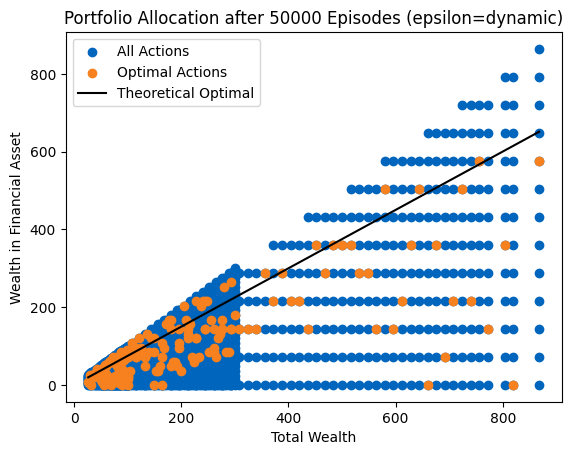


 --- Policy learned after 500000 episodes: ---


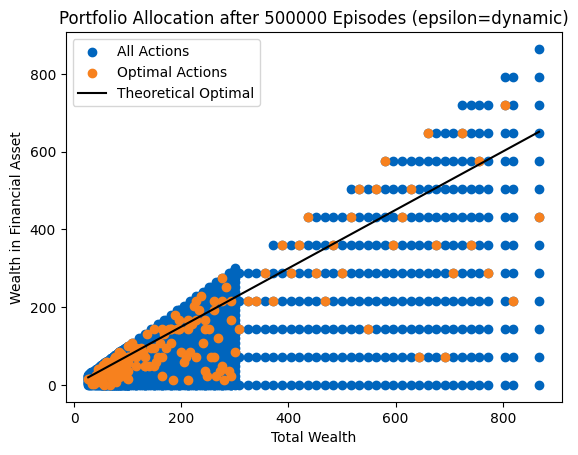


 --- Policy learned after 5000000 episodes: ---


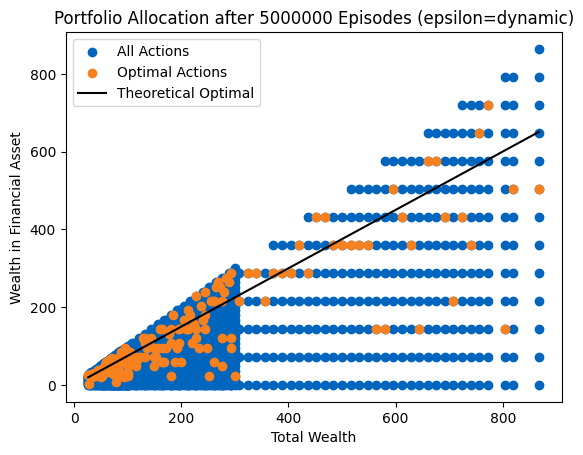


 --- Policy learned after 50000000 episodes: ---


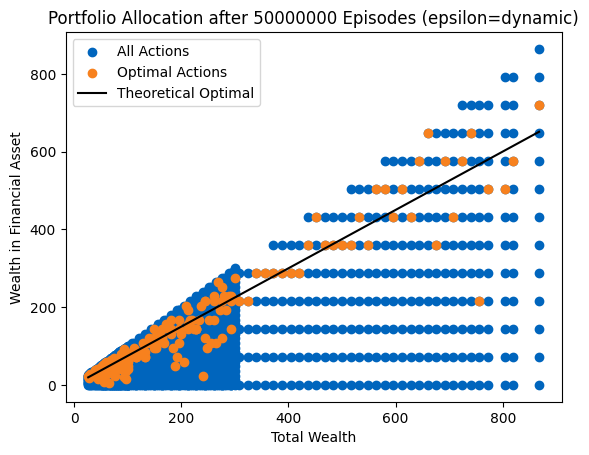

In [67]:
epsilon = "dynamic"     # Dynamic epsilon
#epsilon = 0.2           # Constant epsilon

for episode in episodes_list:
    # Run Q-learning for the specified number of episodes
    Q_table_list = Q_learning(episode, epsilon=epsilon)
    Q_table = Q_table_list[-1]  # Get the last Q-table
    
    # Print the policy learned
    print(f"\n --- Policy learned after {episode} episodes: ---")
    for state in crr_model.states:
        if state in Q_table:
            1 == 1
            #print(f"State {state}: Optimal action {max(Q_table[state], key=Q_table[state].get)}")

    # visualise the policy learned
    filename = f"withTerminalState_portfolio_allocation_{episode}.png"
    visualise_policy(Q_table, crr_model, episode, filename, epsilon)